# LLM Model인 Bert Model을 사용하기 위해서 가능하면 GPU 서버로 진행
> T4 GPU로 변경

# 데이터 테이블 로드

In [1]:
from pathlib import Path

import pandas as pd

ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "storage" / "processed" / "recipe" / "recipe_fix.csv").exists()
)
RECIPE_FIX_CSV = ROOT / "storage" / "processed" / "recipe" / "recipe_fix.csv"
RECIPE_INGRED_ALIAS_CSV = ROOT / "storage" / "processed" / "recipe" / "recipe_ingredient_alias.csv"

ingred = pd.read_csv(RECIPE_INGRED_ALIAS_CSV)
df = pd.read_csv(RECIPE_FIX_CSV)
df.head(1)

,RCP_SNO,CKG_NM,INQ_CNT,SRAP_CNT,CKG_MTH_ACTO_NM,CKG_STA_ACTO_NM,CKG_MTRL_ACTO_NM,CKG_KND_ACTO_NM,CKG_MTRL_CN,CKG_INBUN_NM,...,INQ_CNT_RATE_2024,INQ_CNT_LOG_2024,INQ_CNT_LOG_CENTERED_2024,INQ_CNT_2026,INQ_CNT_2026_CRAWLED_AT_UTC,INQ_CNT_DELTA_2024_2026,INQ_CNT_GROWTH_RATE_2024_2026,INQ_CNT_RATE_2026,INQ_CNT_LOG_2026,INQ_CNT_LOG_CENTERED_2026
0,7016814,된장수육,1396,1,삶기,술안주,돼지고기,메인반찬,"[['돼지고기 수육용삼겹살', '500', 'g'], [' 된장', '1.5', '...",2인분,...,0.022969,7.242082,-0.526618,2042.0,2026-07-07T06:07:03.230726+00:00,646.0,0.462751,0.012285,7.622175,-0.883357


# Install

In [2]:
from pathlib import Path

REQ = next(
    p / "etl" / "recipe" / "profiling" / "requirements.txt"
    for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "etl" / "recipe" / "profiling" / "requirements.txt").exists()
)
!pip install -r "{REQ}"

  Using cached pandas-2.2.2.tar.gz (4.4 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [12 lines of output]
      + meson setup C:\Users\104go\AppData\Local\Temp\pip-install-j7_ueh_v\pandas_c2d11a384e1245c199e2f451c4ff6346 C:\Users\104go\AppData\Local\Temp\pip-install-j7_ueh_v\pandas_c2d11a384e1245c199e2f451c4ff6346\.mesonpy-dn4cl0vp\build -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --vsenv --native-file=C:\Users\104go\AppData\Local\Temp\pip-install-j7_ueh_v\pandas_c2d11a384e1245c199e2f451c4ff6346\.mesonpy-dn4cl0vp\build\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.1
      Source dir: C:\Users\104go\AppData\Local\Temp\pip-install-j7_ueh_v\pandas_c2d11a384e1245c199e2f451c4ff6346
      Build dir: C:\Users\104go\AppData\Local\Temp\pip-install-j7_ueh_v\pandas_c2d11a384e1245c199e2f451c4ff6346\.mesonpy-dn4cl0vp\build
      Build type: native build
      Project name: pandas
      Project version: 2.2.2
    

# [영화 평가 데이터](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset/data)
- 이 파일에는 Full MovieLens 데이터셋에 등록된 45,000편의 영화에 대한 메타데이터가 포함되어 있습니다.
- 이 데이터셋은 2017년 7월 이전에 개봉한 영화로 구성되어 있습니다. 데이터 포인트에는 출연진, 제작진, 줄거리 키워드, 예산, 수익, 포스터, 개봉일, 언어, 제작사, 국가, TMDB 투표 수 및 투표 평균 등이 포함됩니다.
- 이 데이터세트에는 45,000편의 영화에 대해 27만 명의 사용자가 작성한 2,600만 건의 평점이 포함된 파일도 포함되어 있습니다.
- 평점은 1점부터 5점까지의 점수로 매겨지며, GroupLens 공식 웹사이트에서 수집되었습니다.

## 데이터(파일) 설명

- movies_metadata.csv
  - 주요 영화 메타데이터 파일입니다.
  - Full MovieLens 데이터세트에 포함된 45,000편의 영화에 대한 정보가 포함되어 있습니다.
  - 포스터, 배경, 예산, 수익, 개봉일, 언어, 제작 국가 및 제작사 등의 정보가 포함됩니다.
- keywords.csv
  - MovieLens 영화의 줄거리 키워드를 담고 있습니다.
  - 문자열화된 JSON 객체 형태로 제공됩니다.
- links_small.csv
  - 전체 데이터 세트의 9,000개 영화 중 작은 하위 세트의 TMDB 및 IMDB ID를 포함합니다.

# 데이터

In [3]:
# DATA_PATH = "/content/data/MyDrive/ai_lecture/6. Recommendation System/data/Movies Dataset/"

In [4]:
import pandas as pd
from ast import literal_eval

## 데이터 로드

### movies_metadata

> movies_metadata는 영화에 대한 메타데이터(제목, 장르 등)이다.

In [5]:
# movies_metadata = pd.read_csv(DATA_PATH+'movies_metadata.csv')

df.shape

(3171, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3171 entries, 0 to 3170
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   RCP_SNO                        3171 non-null   int64  
 1   CKG_NM                         3171 non-null   object 
 2   INQ_CNT                        3171 non-null   int64  
 3   SRAP_CNT                       3171 non-null   int64  
 4   CKG_MTH_ACTO_NM                3171 non-null   object 
 5   CKG_STA_ACTO_NM                3171 non-null   object 
 6   CKG_MTRL_ACTO_NM               3171 non-null   object 
 7   CKG_KND_ACTO_NM                3171 non-null   object 
 8   CKG_MTRL_CN                    3171 non-null   object 
 9   CKG_INBUN_NM                   3171 non-null   object 
 10  CKG_DODF_NM                    3171 non-null   object 
 11  CKG_TIME_NM                    3171 non-null   object 
 12  INQ_CNT_RATE                   3171 non-null   f

In [7]:
ingred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3171 entries, 0 to 3170
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   RCP_SNO                 3171 non-null   int64 
 1   CKG_NM                  3171 non-null   object
 2   ingredients_raw         3171 non-null   object
 3   aliases_matched         3171 non-null   object
 4   ingredients_normalized  3171 non-null   object
 5   others_count            3171 non-null   int64 
 6   others_items            3171 non-null   object
 7   basic_count             3171 non-null   int64 
 8   basic_items             3171 non-null   object
dtypes: int64(3), object(6)
memory usage: 223.1+ KB


### links_small

> links_small.csv를 이용하여 movies_metadata의 데이터 수를 줄이자   
> 너무 데이터가 많으면, 전처리 및 추천할 때, 시간이 오래 걸리거나 메모리가 부족한 경우가 발생할 수 있다.

In [8]:
# links_small = pd.read_csv(DATA_PATH+'links_small.csv')

# links_small.info()

In [9]:
# # 결측치 제거 및 데이터 형변환
# links_small = links_small[links_small['tmdbId'].notnull()]['tmdbId'].astype('int')
# links_small.shape

In [10]:
# # links_small에 포함된 id만 사용
# movies_metadata_small = movies_metadata[movies_metadata['id'].isin(links_small.astype('str'))]
# movies_metadata_small.shape

### movies_keywords

In [11]:
# movies_keywords = pd.read_csv(DATA_PATH+'keywords.csv')

# movies_keywords.columns

In [12]:
# movies_metadata_small['id'] = movies_metadata_small['id'].astype('str')
# movies_keywords['id'] = movies_keywords['id'].astype('str')

# # 영화 아이디(id)를 기준으로 데이터를 합치기
# movies_metadata_small = movies_metadata_small.merge(movies_keywords, on=['id'])

# # 결과 확인
# movies_metadata_small.shape

> 추천에 사용하는 recipe_fix feature + recipe_ingredient_alias merge
> RCP_SNO, CKG_NM, CKG_KND_ACTO_NM, CKG_MTH_ACTO_NM, CKG_MTRL_ACTO_NM, INQ_CNT_LOG_CENTERED, SRAP_CNT_LOG_CENTERED


In [13]:
columns = [
    'RCP_SNO', 'CKG_NM', 'CKG_KND_ACTO_NM', 'CKG_MTH_ACTO_NM', 'CKG_MTRL_ACTO_NM',
    'INQ_CNT_LOG_CENTERED', 'SRAP_CNT_LOG_CENTERED',
]

movies = df[columns].copy()
movies.head(1)


,RCP_SNO,CKG_NM,CKG_KND_ACTO_NM,CKG_MTH_ACTO_NM,CKG_MTRL_ACTO_NM,INQ_CNT_LOG_CENTERED,SRAP_CNT_LOG_CENTERED
0,7016814,된장수육,메인반찬,삶기,돼지고기,-0.526618,-1.618524


In [14]:
# 조리법 전처리
# 주재료 전처리 
# 재료 목록 전처리 
# 알리아스 전처리 

# 이전에 재료목록이랑 알리아스 레시피 데이터에 합치기 
# ponytail: Just join on RCP_SNO using standard pandas merge, fetch cols, concat as required. Assume ingred is already loaded as a DataFrame and has the needed columns.
# If not, user can adjust variable/dataframe names; the pattern is correct.

# Merge ingred's relevant columns onto movies by RCP_SNO
if 'RCP_SNO' in movies.columns and 'RCP_SNO' in ingred.columns:
    movies = movies.merge(
        ingred[['RCP_SNO', 'aliases_matched', 'ingredients_normalized']],
        on='RCP_SNO',
        how='left'
    )

movies.head(1)

,RCP_SNO,CKG_NM,CKG_KND_ACTO_NM,CKG_MTH_ACTO_NM,CKG_MTRL_ACTO_NM,INQ_CNT_LOG_CENTERED,SRAP_CNT_LOG_CENTERED,aliases_matched,ingredients_normalized
0,7016814,된장수육,메인반찬,삶기,돼지고기,-0.526618,-1.618524,"[{""alias_id"": ""alias_0843"", ""name"": ""삼겹살""}, {""...","[[""삼겹살"", ""500"", ""g""], [""된장"", ""1.5"", ""큰술""], [""술..."


## 데이터 전처리

### 재료·alias 전처리


In [15]:
from ast import literal_eval

movies['str_aliases'] = (
    movies['aliases_matched'].fillna('[]')
    .apply(literal_eval)
    .apply(lambda x: sorted(i['alias_id'] for i in x if isinstance(i, dict) and i.get('alias_id')) if isinstance(x, list) else [])
    .apply(lambda x: ', '.join(x) if x else None)
)

movies['str_ingredients'] = (
    movies['ingredients_normalized'].fillna('[]')
    .apply(literal_eval)
    .apply(lambda x: sorted(item[0] for item in x if isinstance(item, list) and item) if isinstance(x, list) else [])
    .apply(lambda x: ', '.join(x) if x else None)
)

movies[['str_aliases', 'str_ingredients', 'CKG_NM']].head(1)


,str_aliases,str_ingredients,CKG_NM
0,"alias_0157, alias_0251, alias_0559, alias_0617...","된장, 무, 삼겹살, 술, 콩나물, 홍어",된장수육


> 영화 `keywords` 전처리는 레시피 데이터에 해당 컬럼이 없어 생략. `str_ingredients` / `str_aliases` 사용.


In [16]:
pass  # keywords 전처리 불필요


### 레시피 BERT 입력 텍스트


In [17]:
def get_ckg_info(row):
    return f"""
    CKG_NM:
    {row.get('CKG_NM', '')}

    CKG_KND_ACTO_NM:
    {row.get('CKG_KND_ACTO_NM', '')}

    CKG_MTH_ACTO_NM:
    {row.get('CKG_MTH_ACTO_NM', '')}

    CKG_MTRL_ACTO_NM:
    {row.get('CKG_MTRL_ACTO_NM', '')}

    str_aliases:
    {row.get('str_aliases', '')}

    str_ingredients:
    {row.get('str_ingredients', '')}
    """


In [18]:
movies['recipe_text'] = movies.apply(get_ckg_info, axis=1)

movies[['recipe_text', 'str_aliases', 'str_ingredients', 'CKG_NM']].head(2)


,recipe_text,str_aliases,str_ingredients,CKG_NM
0,\n CKG_NM:\n 된장수육\n\n CKG_KND_ACTO_NM...,"alias_0157, alias_0251, alias_0559, alias_0617...","된장, 무, 삼겹살, 술, 콩나물, 홍어",된장수육
1,\n CKG_NM:\n 우거지 감자탕\n\n CKG_KND_ACTO...,"alias_0036, alias_0099, alias_0140, alias_0151...","간장, 감자, 고추장, 고춧가루, 깻잎, 다시다, 대파, 돼지등뼈, 들깨가루, 마늘...",우거지 감자탕


In [19]:
movies[['recipe_text']].loc[0].values[0]


'\n    CKG_NM:\n    된장수육\n\n    CKG_KND_ACTO_NM:\n    메인반찬\n\n    CKG_MTH_ACTO_NM:\n    삶기\n\n    CKG_MTRL_ACTO_NM:\n    돼지고기\n\n    str_aliases:\n    alias_0157, alias_0251, alias_0559, alias_0617, alias_0688, alias_0843\n\n    str_ingredients:\n    된장, 무, 삼겹살, 술, 콩나물, 홍어\n    '

### 인기도 feature (recipe_fix)


In [20]:
# # release_date의 데이터 타입이 문자열(object)임을 확인할 수 있다.
# movies.info()

> errors='coerce'를 입력하면, 변환할 수 있는 데이터는 수치형으로 변환되고 변환할 수 없는 데이터는 NaN으로 처리됩니다.   
> NaN은 Not a Number의 약자입니다.

In [21]:
# # 문자열(object)를 날짜(datetime64)로 데이터 형변환
# movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

# # 결과 확인
# movies.info()

> release_date를 이용하여 year(년도)를 추출하자   
> 추천을 할때 가능하면 최신 년도를 추천하자

In [22]:
# movies['year'] = movies['release_date'].dt.year

# movies[['release_date', 'year']].head()

### 영화 인기도(popularity)

In [23]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3171 entries, 0 to 3170
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   RCP_SNO                 3171 non-null   int64  
 1   CKG_NM                  3171 non-null   object 
 2   CKG_KND_ACTO_NM         3171 non-null   object 
 3   CKG_MTH_ACTO_NM         3171 non-null   object 
 4   CKG_MTRL_ACTO_NM        3171 non-null   object 
 5   INQ_CNT_LOG_CENTERED    3171 non-null   float64
 6   SRAP_CNT_LOG_CENTERED   3171 non-null   float64
 7   aliases_matched         3171 non-null   object 
 8   ingredients_normalized  3171 non-null   object 
 9   str_aliases             3167 non-null   object 
 10  str_ingredients         3171 non-null   object 
 11  recipe_text             3171 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 297.4+ KB


In [24]:
# # 문자열을 실수값으로 변경
# movies['popularity'] = movies['popularity'].astype(float)

In [25]:
# import numpy as np

# # 문자열을 실수값으로 변경
# movies['popularity_log'] = np.log(movies['popularity'])

# # log를 이용해서 왜도 해결
# movies[['popularity_log', 'popularity']].describe()

<Axes: xlabel='INQ_CNT_LOG_CENTERED', ylabel='Count'>

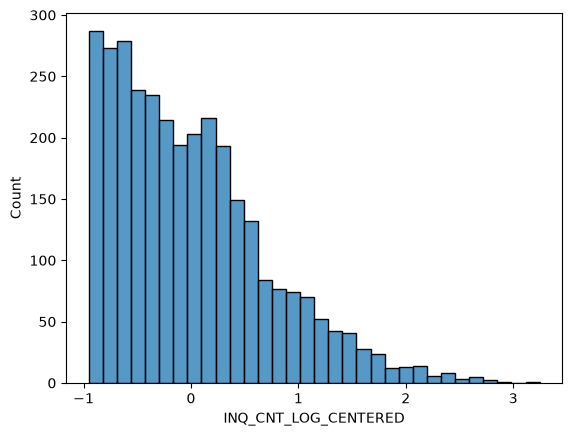

In [26]:
import seaborn as sns

sns.histplot(movies['INQ_CNT_LOG_CENTERED'])

## 데이터 결측치 제거

> 각 컬럼별 결측치 비율 확인

```python
# movies.isnull().sum() -> 컬럼별 결측치의 합
# movies.shape[0] -> 전체 데이터의 수
# (movies.isnull().sum() / movies.shape[0])
# -> 각 컬럼별 결측치의 비율
(movies.isnull().sum() / movies.shape[0])\
  # 소수점 4자리까지만 표현
  .round(4)\
  # 가장 높은 비율(결측치) 순으로 정렬
  .sort_values(ascending=False)

```

In [27]:
print(f"movies.shape: {movies.shape}")
(movies.isnull().sum() / movies.shape[0])\
  .round(4)\
  .sort_values(ascending=False)

movies.shape: (3171, 12)


str_aliases               0.0013
RCP_SNO                   0.0000
CKG_KND_ACTO_NM           0.0000
CKG_NM                    0.0000
CKG_MTH_ACTO_NM           0.0000
CKG_MTRL_ACTO_NM          0.0000
SRAP_CNT_LOG_CENTERED     0.0000
INQ_CNT_LOG_CENTERED      0.0000
aliases_matched           0.0000
ingredients_normalized    0.0000
str_ingredients           0.0000
recipe_text               0.0000
dtype: float64

> 결측치 데이터 제거하기

In [28]:
# 결측치 데이터 제거
movies = movies.dropna()
# 인덱스 재정의
movies = movies.reset_index(drop=True)

# 확인
print(f"movies.shape: {movies.shape}")
(movies.isnull().sum() / movies.shape[0])\
  .round(4)\
  .sort_values(ascending=False)

movies.shape: (3167, 12)


RCP_SNO                   0.0
CKG_NM                    0.0
CKG_KND_ACTO_NM           0.0
CKG_MTH_ACTO_NM           0.0
CKG_MTRL_ACTO_NM          0.0
INQ_CNT_LOG_CENTERED      0.0
SRAP_CNT_LOG_CENTERED     0.0
aliases_matched           0.0
ingredients_normalized    0.0
str_aliases               0.0
str_ingredients           0.0
recipe_text               0.0
dtype: float64

# LLM 기반 Contents Based Filtering

## Embedding
- Embedding은 단어, 문장, 이미지 등과 같은 복잡한 데이터를 숫자 벡터로 바꿔주는 방식입니다.
- 이 벡터는 원본 데이터의 의미나 특징을 가능한 한 잘 유지하면서 AI가 이해하고 계산할 수 있도록 해줍니다.

Bert Model을 이용해서 Embedding을 하면, 기존에 배웠단 `단어간의 빈도 수가 아닌` 아래 이미지와 같이 `토큰(단어)간의 관계성`에 대한 벡터화를 진행할 수 있습니다.

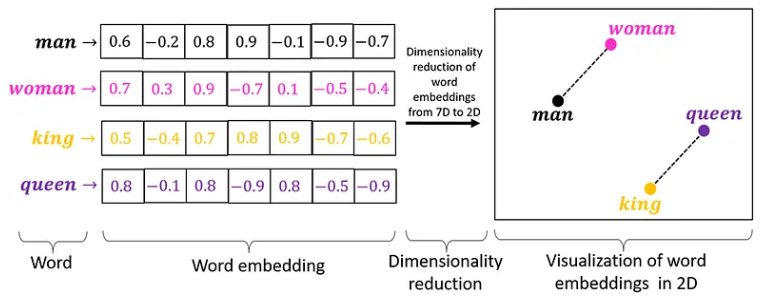

## BERT LLM (Large Language Model, 거대 언어 모델)
- BERT(Bidirectional Encoder Representations from Transformers)는 2018년 Google이 발표한 대표적인 LLM(대형 언어 모델) 중 하나입니다.
- BERT의 대표 활용 예
  - 질문 응답 시스템 (예: "Where was Obama born?" → "Hawaii")
  - 문장 분류 (예: 긍정/부정 판단)
  - `문장 유사도 측정`
  - 검색엔진 개선 (Google 검색도 BERT 사용 중)

### Bert Model을 이용한 유사도 측정
1. Bert Model을 이용해서 각 문장을 백터로 변환
  -  변환된 백터 데이터는 단어간의 의미가 반영된 정보임
2. 해당 백터 데이터를 코사인 유사도를 이용하여 유사도값을 계산

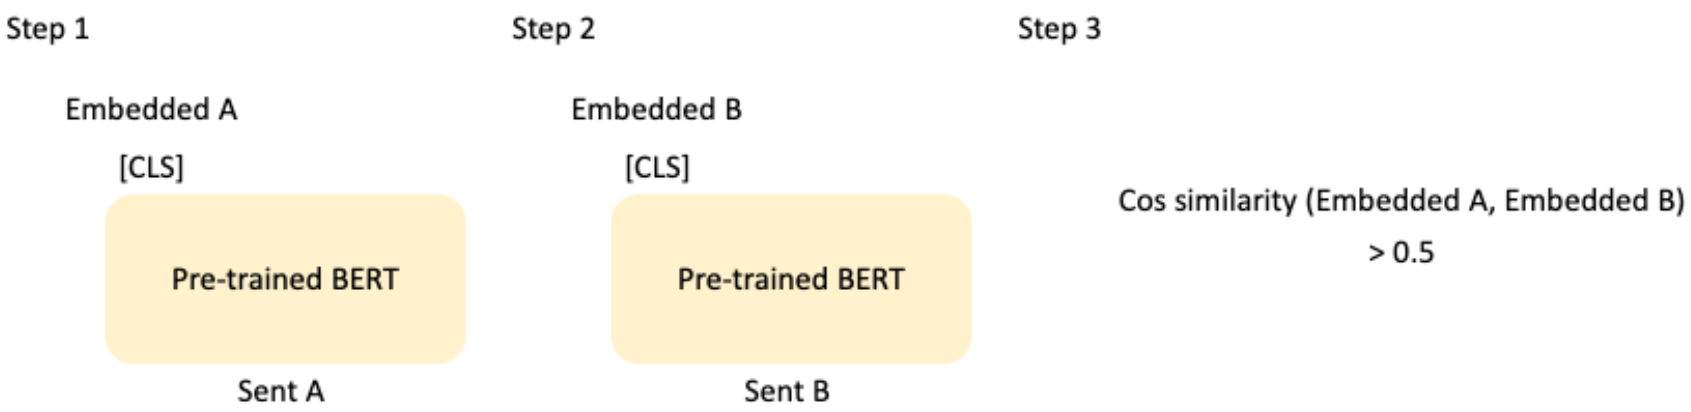

In [29]:
from transformers import BertTokenizer, BertModel
import torch

model_name = "bert-base-uncased"

### GPU 사용 유무

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Tokenizer

> Tokenizer는 인간의 언어(문장, 단어)를 모델이 이해할 수 있는 단위인 "토큰(token)"으로 쪼개주는 도구입니다.

In [31]:
tokenizer = BertTokenizer.from_pretrained(model_name)

#### 토크나이즈 예제

1. 문장을 토큰으로 분할

In [32]:
# 입력 문장 정의
sentence = "Transformers are amazing!"

# 토크나이즈 (토큰 분할)
tokens = tokenizer.tokenize(sentence)
tokens

['transformers', 'are', 'amazing', '!']

2. 토큰을 index로 변환

In [33]:
# 토큰을 id(index)로 변환
token_ids = tokenizer.convert_tokens_to_ids(tokens)
token_ids

[19081, 2024, 6429, 999]

3. Bert Model 인풋 데이터로 변환

- `return_tensors='pt'`는 PyTorch 텐서 형태로 반환하도록 설정한 것입니다.

| 항목               | 의미                      | 예시 값                     |
| ---------------- | ----------------------- | ------------------------ |
| `input_ids`      | 문장의 토큰 ID 시퀀스           | `[101, 19081, ..., 102]` |
| `token_type_ids` | 문장 구분 (0: 문장1, 1: 문장2)  | `[0, 0, 0, 0, 0, 0]`     |
| `attention_mask` | 토큰 처리 여부 (1: 처리, 0: 무시) | `[1, 1, 1, 1, 1, 1]`     |


In [34]:
# 전체 인코딩 (토큰 + 스페셜 토큰 + 패딩 등 자동 처리)
encoded = tokenizer(sentence, return_tensors='pt')
encoded

{'input_ids': tensor([[  101, 19081,  2024,  6429,   999,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}

4. 인풋 데이터 중 특수 토큰의 의미 확인

- `101`과 `102`는 `[CLS]`, `[SEP]` 토큰 (BERT 전용 특수 토큰)입니다.
  - [CLS](Classification token): 항상 문장의 맨 앞에 추가됩니다.
  - [SEP](Separator token): 단일 문장일 때는 문장 끝에 하나 붙이고, 두 문장 입력할 때는 두 문장 사이를 나누는 데 사용됩니다.

In [35]:
input_ids = encoded['input_ids'][0]
input_ids

tensor([  101, 19081,  2024,  6429,   999,   102])

5. 인풋 데이터를 다시 문자 데이터로 변환

In [36]:
# 디코딩 (숫자 → 텍스트)
decoded_sentence = tokenizer.decode(input_ids)
decoded_sentence

'[CLS] transformers are amazing! [SEP]'

### Bert Model

In [37]:
model = BertModel.from_pretrained(model_name).to(device)
model.eval() # 예측모드

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

c:\dev\project\SKN27-FINAL-1Team\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\104go\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP dow

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dropout(p=

### BERT Embedding

In [38]:
def get_bert_embedding(text):
    # text를 토큰화 처리
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)

    # BERT를 이용하여 벡터화(예측)
    with torch.no_grad():
        outputs = model(**inputs)

    # outputs.last_hidden_state는 (batch_size(배치), sequence_length(토큰), hidden_size(벡터))와 같은 3차원 데이터이다.
    # -> 이 마지막 차원(last_hidden_state)이 hidden_size의 데이터가 우리가 원하는 임베딩 결과 데이터이다.
    # BERT는 입력 문장 앞에 항상 [CLS] 토큰을 붙이고, 이 토큰의 출력은 문장 전체를 대표하도록 학습합니다.
    # -> 따라서 [CLS] 토큰의 출력값을 사용
    # -> [CLS]는 문장의 맨앞에 위치하기 때문에 [:, 0, :]을 이용해서 추출 가능
    return outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

In [39]:
from tqdm import tqdm

tqdm.pandas()

movies['embedding'] = movies['recipe_text'].progress_apply(get_bert_embedding)


100%|██████████| 3167/3167 [07:54<00:00,  6.68it/s]


In [40]:
movies[['embedding', 'recipe_text']].head()


,embedding,recipe_text
0,"[-0.28422514, 0.19114992, 0.0057565495, 0.0002...",\n CKG_NM:\n 된장수육\n\n CKG_KND_ACTO_NM...
1,"[-0.11636575, 0.38152614, -0.26754, -0.0842496...",\n CKG_NM:\n 우거지 감자탕\n\n CKG_KND_ACTO...
2,"[-0.24122533, 0.23935446, -0.23429883, -0.0958...",\n CKG_NM:\n 만두전골\n\n CKG_KND_ACTO_NM...
3,"[-0.15915966, 0.16548401, -0.0664856, -0.30505...",\n CKG_NM:\n 무수분보쌈\n\n CKG_KND_ACTO_N...
4,"[-0.10962467, 0.103831336, -0.054686327, 0.004...",\n CKG_NM:\n 참치 카나페\n\n CKG_KND_ACTO_...


### Cosine Similarity

In [41]:
all_embeddings = movies['embedding'].values.tolist()

In [42]:
import numpy as np

# python list를 numpy array로 변환
all_embeddings = np.array(all_embeddings)

# shape -> (전체 데이터 수, BERT Embedding 크기)
all_embeddings.shape

(3167, 768)

In [43]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_of_overview = cosine_similarity(all_embeddings, all_embeddings)

# shape -> (전체 데이터 수, 전체 데이터 수)
similarity_of_overview.shape

(3167, 3167)

In [44]:
# 유사도 데이터를 index 데이터로 변환 및 정렬 작업
sorted_similarity_of_overview = similarity_of_overview.argsort()[:, ::-1]

## 추천하기

In [45]:
def recommendation(ckg_name, top_k=5):
    recipe = movies[movies['CKG_NM'] == ckg_name]
    if recipe.empty:
        raise ValueError(f'레시피 없음: {ckg_name}')
    print(f"{ckg_name} 재료: {recipe['str_ingredients'].values[0]}")

    recipe_index = recipe.index.values[0]
    similar_indexes = sorted_similarity_of_overview[recipe_index, :(top_k * 2)].reshape(-1)
    similar_indexes = similar_indexes[similar_indexes != recipe_index]

    return movies.iloc[similar_indexes].sort_values(
        by=['INQ_CNT_LOG_CENTERED', 'SRAP_CNT_LOG_CENTERED'],
        ascending=False,
    )[:top_k]


In [47]:
recommendation_recipes = recommendation('떡국')

recommendation_recipes[[
    'CKG_NM', 'CKG_KND_ACTO_NM', 'CKG_MTH_ACTO_NM', 'CKG_MTRL_ACTO_NM',
    'str_ingredients', 'INQ_CNT_LOG_CENTERED', 'SRAP_CNT_LOG_CENTERED',
]]


떡국 재료: 계란, 김, 대파, 떡국떡, 멸치, 물, 설탕, 소고기, 식용유, 표고버섯


,CKG_NM,CKG_KND_ACTO_NM,CKG_MTH_ACTO_NM,CKG_MTRL_ACTO_NM,str_ingredients,INQ_CNT_LOG_CENTERED,SRAP_CNT_LOG_CENTERED
3078,사골떡만두국,국/탕,끓이기,기타,"간장, 대파, 떡국떡, 마늘, 만두, 사골육수, 조미김, 통깨, 후추",0.961990,-1.213059
3160,단호박롤까스,양식,굽기,돼지고기,"계란, 돼지고기 등심, 미니단호박, 밀가루, 빵가루, 설탕, 소금, 식용유, 호두,...",0.915870,1.978788
356,꽈리고추찜무침,밑반찬,무침,채소류,"고춧가루, 까나리액젓, 꽈리고추, 대파, 마늘, 매실청, 물엿, 밀가루, 참기름, 참치액",0.613589,0.578700
1366,또띠아달걀토스트,빵,굽기,채소류,"달걀, 당근, 또띠아, 모짜렐라치즈, 설탕, 양배추, 양파, 체다치즈, 케첩",-0.116629,2.332719
2067,빨간소고기무국,국/탕,끓이기,소고기,"고춧가루, 까나리액젓, 대파, 마늘, 맛술, 무, 물, 소고기, 참치액, 후춧가루",-0.123302,-0.114447
